# Indoor VPR experiment workbench

Change the dataset and algorithm in **Configuration**, then run all cells. Similarities are streamed to CSV so large experiments do not keep the full matrix in memory.


In [4]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import importlib
import indoor_vpr.algorithms.cosplace as cosplace_module
importlib.reload(cosplace_module)

from indoor_vpr import DatasetConfig, ImageDataset, create_algorithm, list_algorithms, stream_vpr_similarity_csv
from indoor_vpr.visualization import show_matches

print('Algorithms:', list_algorithms())


Algorithms: ['anyloc', 'cosplace', 'dinov2', 'mixvpr', 'netvlad', 'rgb_histogram']


## Configuration

This is the only cell you normally need to edit. Use `rgb_histogram` for a quick baseline or `dinov2`, `mixvpr`, `cosplace`, `netvlad`, and `anyloc` for learned descriptors. Set either limit to `None` to use every image.

In [6]:
# Dataset: change these two folders for a new experiment.
DATASET_ROOT = PROJECT_ROOT / 'datasets' / 'dataset-2'
DATABASE_DIR = DATASET_ROOT / 'frames-IMG_3609'
QUERY_DIR = DATASET_ROOT / 'frames-IMG_3610'
MAX_DATABASE_IMAGES = None
MAX_QUERY_IMAGES = None

# Every official SF-XL CosPlace checkpoint. Only these backbone/dimension pairs are valid.
COSPLACE_OUTPUT_DIMS = {'VGG16': [64, 128, 256, 512], 'ResNet18': [32, 64, 128, 256, 512],
                        'ResNet50': [32, 64, 128, 256, 512, 1024, 2048],
                        'ResNet101': [32, 64, 128, 256, 512, 1024, 2048],
                        'ResNet152': [32, 64, 128, 256, 512, 1024, 2048]}
BATCH_SIZE = 8  # Reduce for the larger ResNets if memory is limited.
COSPLACE_CONFIGURATIONS = {
    f'{backbone}_{output_dim}': {'backbone': backbone, 'fc_output_dim': output_dim, 'image_size': 512, 'batch_size': BATCH_SIZE}
    for backbone, output_dims in COSPLACE_OUTPUT_DIMS.items() for output_dim in output_dims
}

# Run one preset or use list(COSPLACE_CONFIGURATIONS) to run all 30 official variants.
SELECTED_CONFIGURATIONS = ['ResNet152_2048', 'ResNet101_2048', 'ResNet50_2048', 'ResNet18_512', 'VGG16_512']
# SELECTED_CONFIGURATIONS = list(COSPLACE_CONFIGURATIONS)
unknown = set(SELECTED_CONFIGURATIONS) - set(COSPLACE_CONFIGURATIONS)
if unknown: raise ValueError(f'Unknown CosPlace configuration(s): {sorted(unknown)}')

ALGORITHM = 'cosplace'
TOP_K = 5
SIMILARITY_CSV_PATHS = {name: PROJECT_ROOT / 'outputs' / 'cosplace' / f'_cosplace_{name.lower()}_similarity.csv' for name in SELECTED_CONFIGURATIONS}
for name in SELECTED_CONFIGURATIONS:
    config = COSPLACE_CONFIGURATIONS[name]
    print(f"{name}: {config['backbone']} | {config['fc_output_dim']}-D | input 512x512 | batch {config['batch_size']}")

ResNet152_2048: ResNet152 | 2048-D | input 512x512 | batch 8
ResNet101_2048: ResNet101 | 2048-D | input 512x512 | batch 8
ResNet50_2048: ResNet50 | 2048-D | input 512x512 | batch 8
ResNet18_512: ResNet18 | 512-D | input 512x512 | batch 8
VGG16_512: VGG16 | 512-D | input 512x512 | batch 8


## Load the selected dataset

In [7]:
dataset_config = DatasetConfig(
    database_dir=DATABASE_DIR,
    query_dir=QUERY_DIR,
    max_database_images=MAX_DATABASE_IMAGES,
    max_query_images=MAX_QUERY_IMAGES,
)
dataset = ImageDataset.from_config(dataset_config)
print(dataset.summary())

Database: 9318 images | Queries: 4284 images


## Run retrieval

In [8]:
for config_name in SELECTED_CONFIGURATIONS:
    config = COSPLACE_CONFIGURATIONS[config_name]
    algorithm = create_algorithm(ALGORITHM, **config)
    csv_path = SIMILARITY_CSV_PATHS[config_name]
    print(f'\nRunning {algorithm.name}: {config_name}')
    results = stream_vpr_similarity_csv(dataset, algorithm, csv_path=csv_path, progress_every=500, top_k=TOP_K)
    print(f'Done: {results.similarity.shape[0]} queries x {results.similarity.shape[1]} database images')
    print(f'Similarity CSV saved to: {csv_path}')


100%|██████████| 239M/239M [05:32<00:00, 754kB/s]  



Running cosplace: ResNet152_2048
Encoding database descriptors...
Encoded 9318/9318 database images.
Encoding queries and streaming similarity rows...
Wrote 500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/cosplace/_cosplace_resnet152_2048_similarity.csv
Wrote 1000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/cosplace/_cosplace_resnet152_2048_similarity.csv
Wrote 1500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/cosplace/_cosplace_resnet152_2048_similarity.csv
Wrote 2000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/cosplace/_cosplace_resnet152_2048_similarity.csv
Wrote 2500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/cosplace/_cosplace_resnet152_2048_similarity.csv
Wrote 3000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/cosplace/_cosplace_resnet152_2048_similarity.csv
Wrote 3500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/cosplace/_cosplace_resnet152_2048_similarity.csv
Wr

100%|██████████| 179M/179M [03:56<00:00, 792kB/s]  



Running cosplace: ResNet101_2048
Encoding database descriptors...
Encoded 9318/9318 database images.
Encoding queries and streaming similarity rows...
Wrote 500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/cosplace/_cosplace_resnet101_2048_similarity.csv
Wrote 1000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/cosplace/_cosplace_resnet101_2048_similarity.csv
Wrote 1500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/cosplace/_cosplace_resnet101_2048_similarity.csv
Wrote 2000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/cosplace/_cosplace_resnet101_2048_similarity.csv
Wrote 2500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/cosplace/_cosplace_resnet101_2048_similarity.csv
Wrote 3000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/cosplace/_cosplace_resnet101_2048_similarity.csv
Wrote 3500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/cosplace/_cosplace_resnet101_2048_similarity.csv
Wr

100%|██████████| 57.1M/57.1M [01:09<00:00, 864kB/s] 



Running cosplace: VGG16_512
Encoding database descriptors...
Encoded 9318/9318 database images.
Encoding queries and streaming similarity rows...
Wrote 500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/cosplace/_cosplace_vgg16_512_similarity.csv
Wrote 1000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/cosplace/_cosplace_vgg16_512_similarity.csv
Wrote 1500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/cosplace/_cosplace_vgg16_512_similarity.csv
Wrote 2000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/cosplace/_cosplace_vgg16_512_similarity.csv
Wrote 2500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/cosplace/_cosplace_vgg16_512_similarity.csv
Wrote 3000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/cosplace/_cosplace_vgg16_512_similarity.csv
Wrote 3500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/cosplace/_cosplace_vgg16_512_similarity.csv
Wrote 4000/4284 query rows to /Users/armin

## Inspect the outputs

This section is self-contained: it reloads the dataset and the saved similarity CSV directly from disk, so you can run it without rerunning the expensive retrieval step.


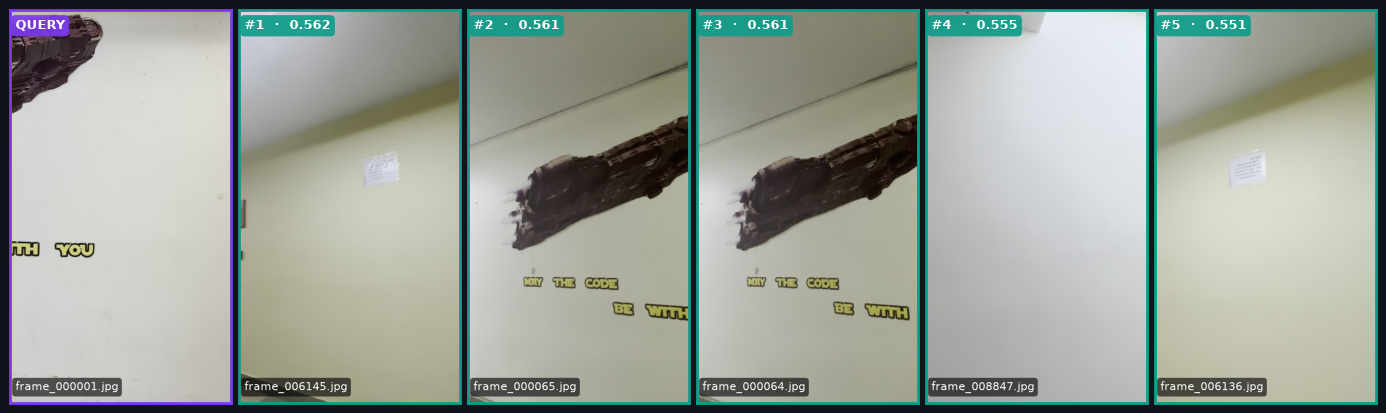

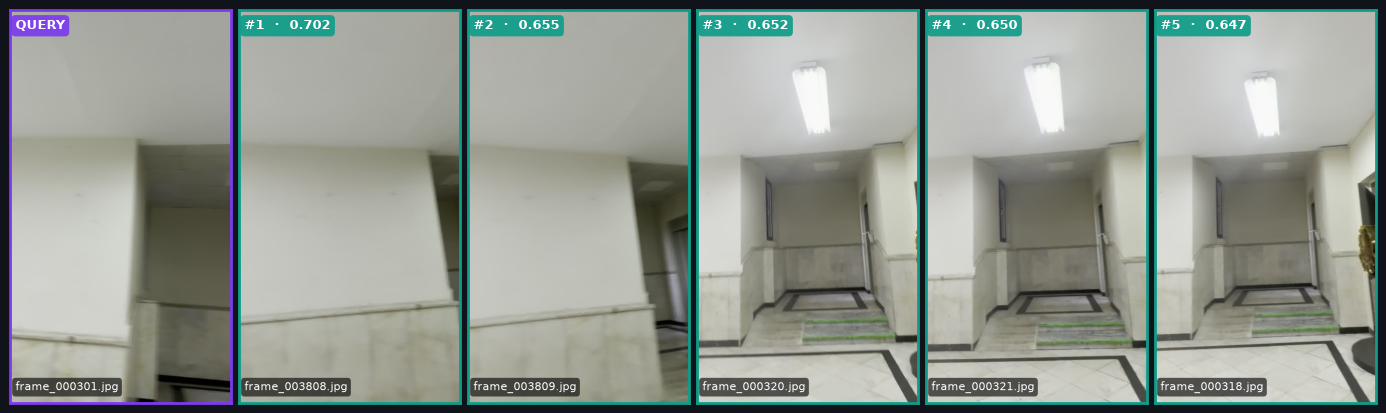

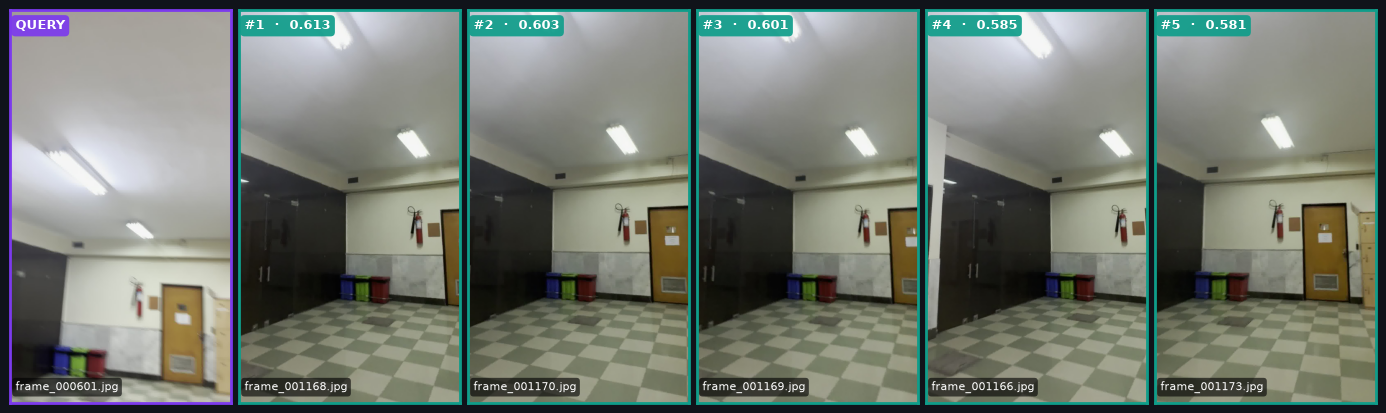

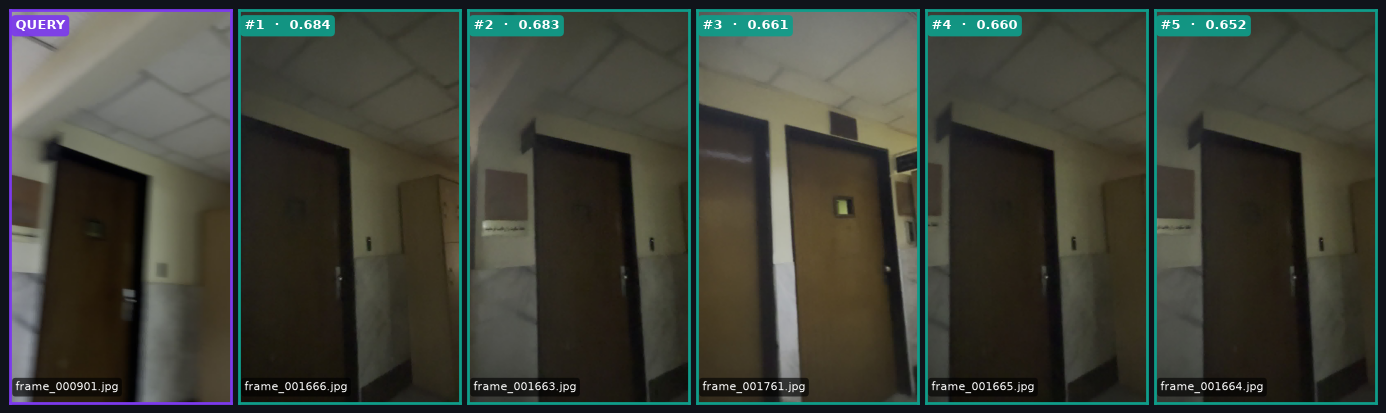

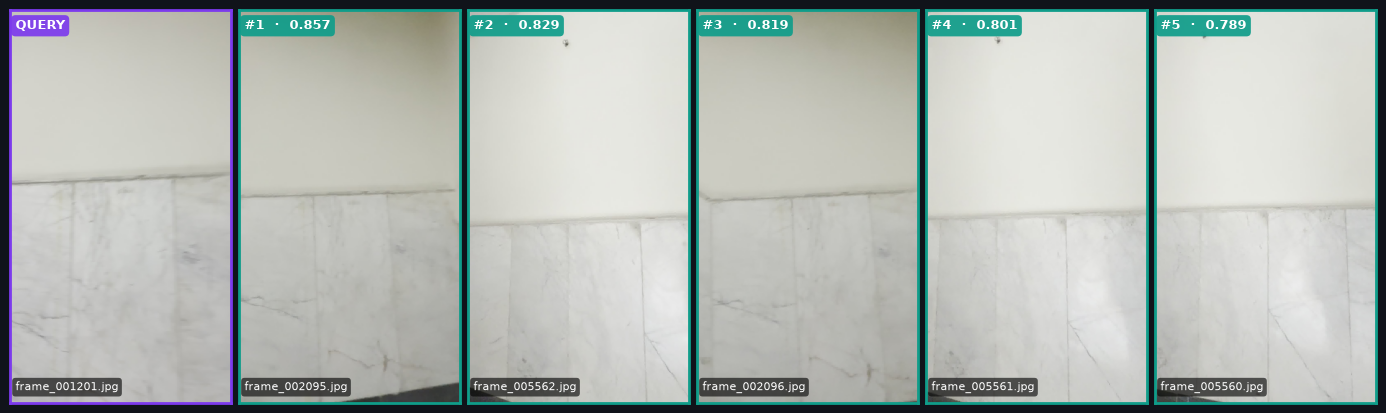

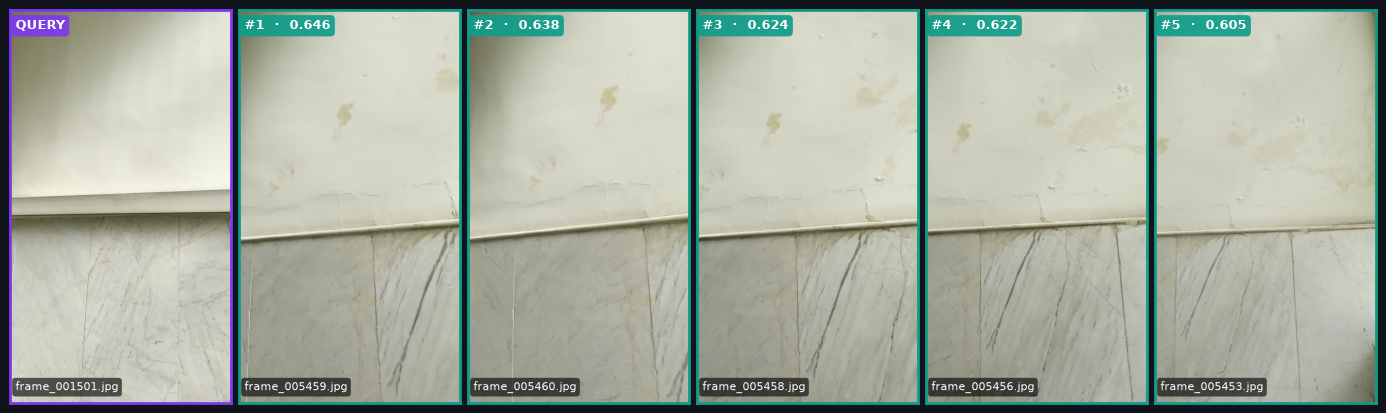

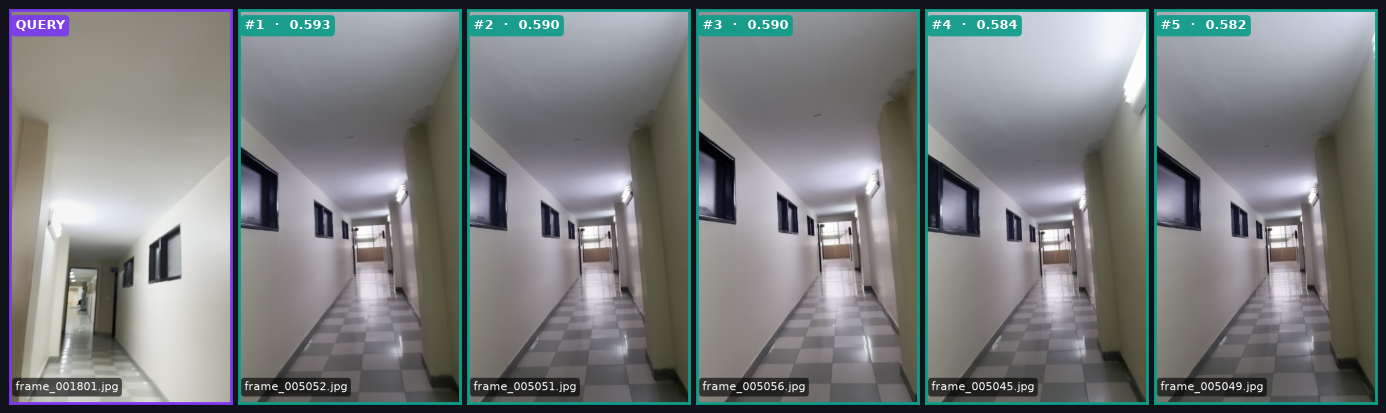

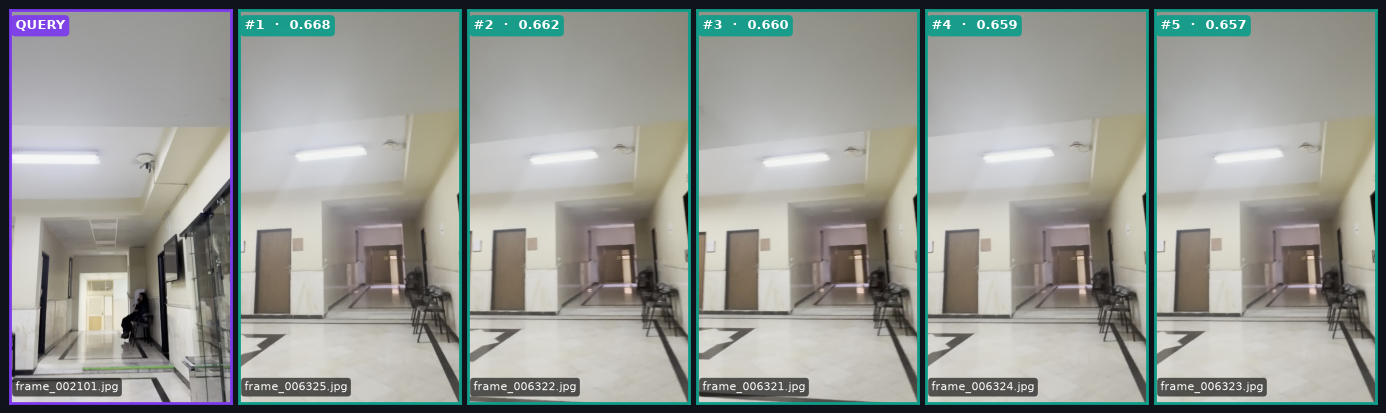

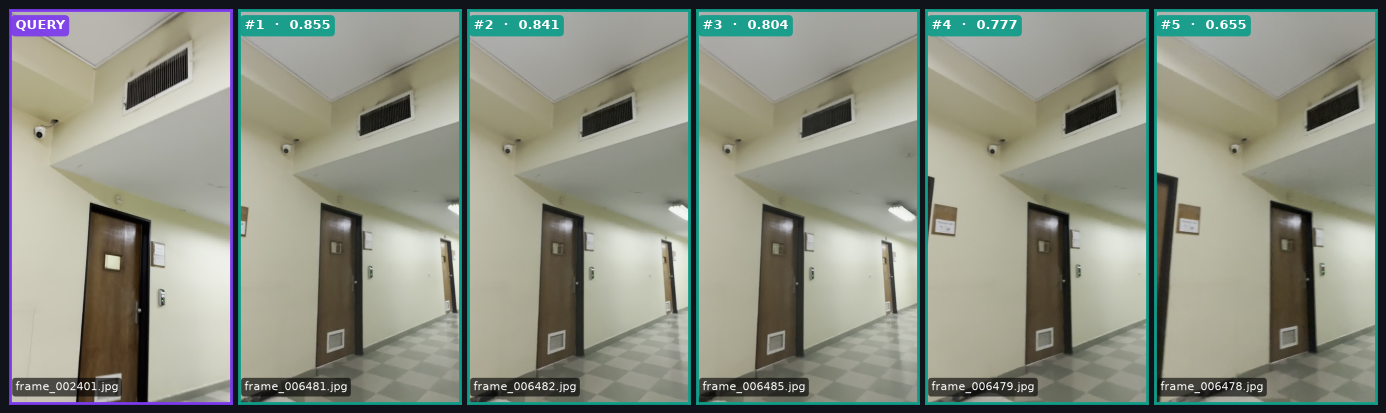

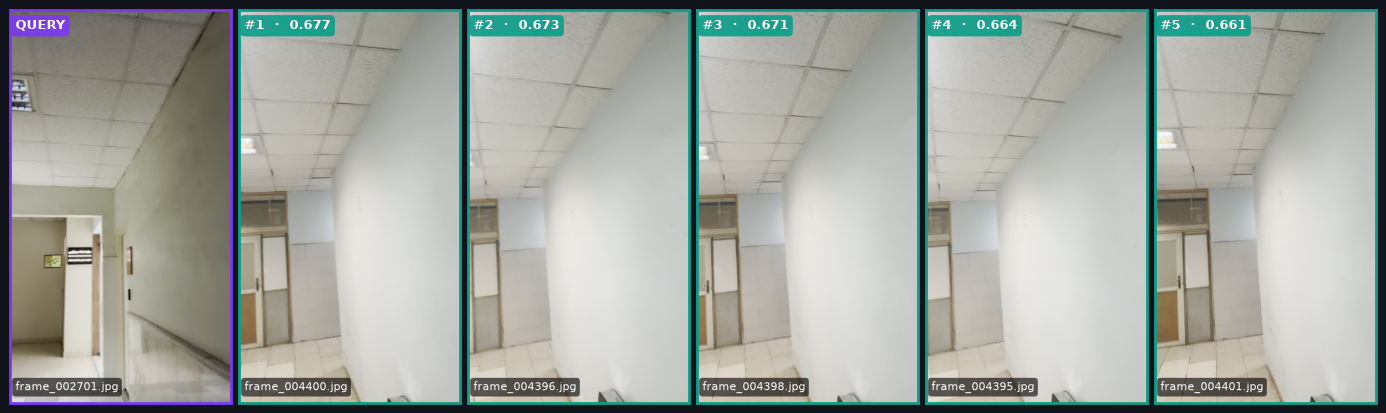

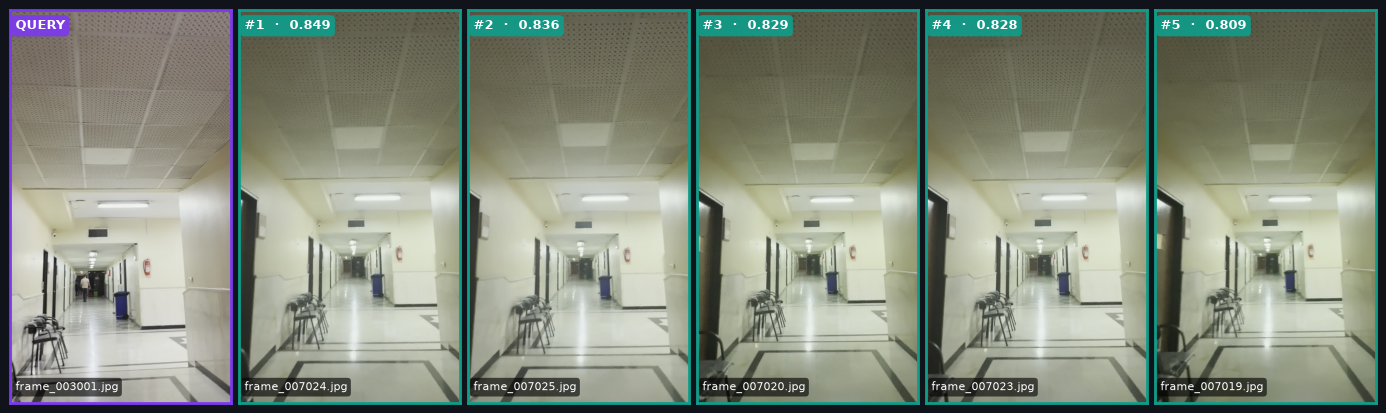

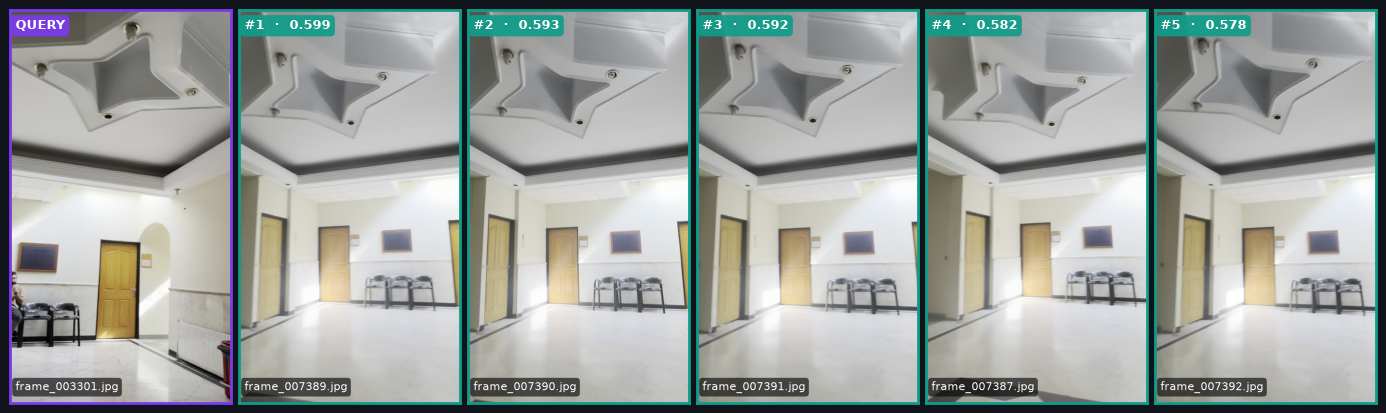

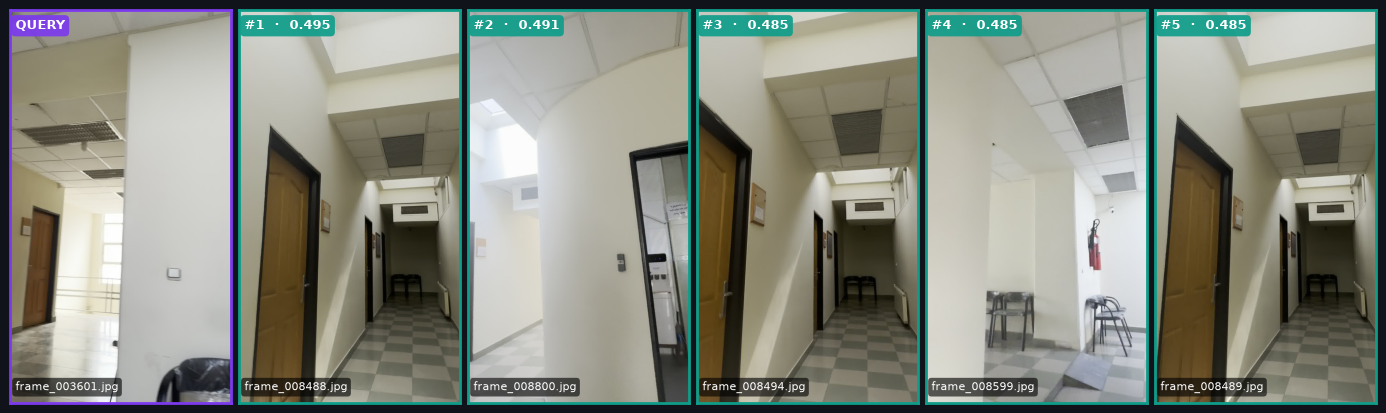

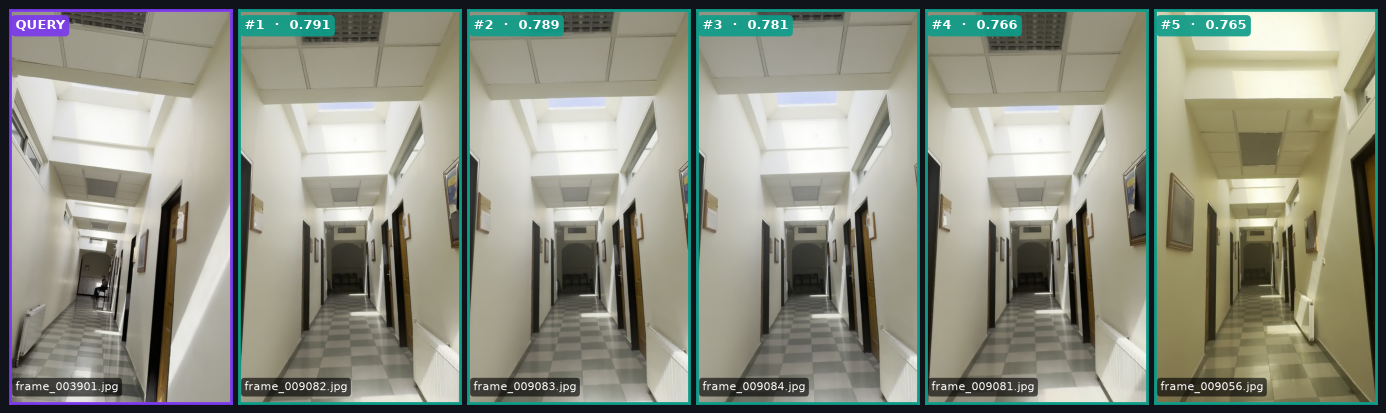

In [10]:
from pathlib import Path
import csv
import sys

import numpy as np

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from indoor_vpr import DatasetConfig, ImageDataset
from indoor_vpr.visualization import show_matches

# Select the completed configuration whose CSV you want to inspect.
INSPECT_CONFIGURATION = 'ResNet50_2048'
ALGORITHM = 'cosplace'
DATASET_ROOT = PROJECT_ROOT / 'datasets' / 'dataset-2'
DATABASE_DIR = DATASET_ROOT / 'frames-IMG_3609'
QUERY_DIR = DATASET_ROOT / 'frames-IMG_3610'
MAX_DATABASE_IMAGES = None
MAX_QUERY_IMAGES = None
TOP_K = 5
SIMILARITY_CSV_PATH = PROJECT_ROOT / 'outputs' / 'cosplace' / f'_cosplace_{INSPECT_CONFIGURATION.lower()}_similarity.csv'

dataset_config = DatasetConfig(
    database_dir=DATABASE_DIR,
    query_dir=QUERY_DIR,
    max_database_images=MAX_DATABASE_IMAGES,
    max_query_images=MAX_QUERY_IMAGES,
)
dataset = ImageDataset.from_config(dataset_config)

if not SIMILARITY_CSV_PATH.is_file():
    raise FileNotFoundError(f'Similarity CSV not found: {SIMILARITY_CSV_PATH}')

class CSVSimilarityView:
    def __init__(self, csv_path: Path, query_count: int, database_count: int) -> None:
        self.csv_path = Path(csv_path)
        self.query_count = query_count
        self.database_count = database_count
        self._row_cache: dict[int, np.ndarray] = {}

    @property
    def shape(self) -> tuple[int, int]:
        return self.query_count, self.database_count

    def row(self, query_index: int) -> np.ndarray:
        if not 0 <= query_index < self.query_count:
            raise IndexError(f"query_index must be between 0 and {self.query_count - 1}")
        if query_index in self._row_cache:
            return self._row_cache[query_index]
        with self.csv_path.open(newline="") as handle:
            reader = csv.reader(handle)
            header = next(reader, None)
            if header is None:
                raise ValueError(f"Similarity CSV is empty: {self.csv_path}")
            for row_number, row in enumerate(reader):
                if row_number == query_index:
                    values = np.asarray(row[2:], dtype=np.float32)
                    self._row_cache[query_index] = values
                    return values
        raise IndexError(f"query_index out of range for CSV: {query_index}")

    def __getitem__(self, key):
        query_index, database_index = key
        return float(self.row(int(query_index))[int(database_index)])

class CSVBackedResults:
    def __init__(self, dataset, similarity):
        self.dataset = dataset
        self.similarity = similarity

    def top_indices(self, query_index: int, top_k: int = 5) -> np.ndarray:
        row = self.similarity.row(query_index)
        if top_k >= len(row):
            return np.argsort(-row)
        candidate_indices = np.argpartition(row, -top_k)[-top_k:]
        return candidate_indices[np.argsort(-row[candidate_indices])]

inspect_results = CSVBackedResults(
    dataset=dataset,
    similarity=CSVSimilarityView(SIMILARITY_CSV_PATH, len(dataset.query_paths), len(dataset.database_paths)),
)

QUERY_INDEX = 5  # Change this to inspect another query.
for i in range(0, 4000, 300):
    show_matches(inspect_results, query_index=i, top_k=TOP_K)
